# 03. Modeling & Evaluation

구현: `src/train.py` — 학습 28 / 홀드아웃 8 (정책 단위, seed 20261001) → 정책 그룹 4-fold CV → 선택 고정 → 홀드아웃 → B2 (·B3)

In [1]:
# ── 공통 설정 ──────────────────────────────────────────────
import sys
from pathlib import Path

# notebooks/ 에서 실행해도 프로젝트 루트의 src 패키지를 import 할 수 있도록 경로 추가
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트(macOS) + 마이너스 기호 깨짐 방지
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="AppleGothic")

# 배치별 색상 (Day 1 산출물과 동일한 톤)
BATCH_COLOR = {"B1": "#2f6b9a", "B2": "#c77d2a", "B3": "#7f5aa6"}

from src.train import main

# 전체 파이프라인 실행 (CV 비교 → 최종 모델 선택 → 홀드아웃·B2·B3 평가 → results/*.csv 저장)
# out: train / holdout / cv / final / model / pred / table / detail
out = main()

         model          features target  cv_mape  cv_std  vs_best_ridge_%p  folds_improved
      Baseline                 -    raw    16.43    1.39              7.47               0
         Ridge                dQ    raw     8.95    2.21              0.00               0
         Ridge                dQ    log     9.04    1.99              0.09               1
         Ridge        policy_raw    raw    15.90    0.85              6.95               0
         Ridge        policy_raw    log    13.90    3.12              4.95               1
         Ridge    policy_derived    raw    13.70    3.12              4.75               0
         Ridge    policy_derived    log    13.40    3.24              4.45               0
         Ridge     dQ+policy_raw    raw    10.29    1.57              1.33               1
         Ridge     dQ+policy_raw    log    10.02    2.09              1.07               1
         Ridge dQ+policy_derived    raw    10.35    2.95              1.40               0

## 1. CV 모델 비교
채택 기준: 최선 Ridge 대비 MAPE 1%p 이상 감소 + 4개 중 3개 폴드 개선

In [2]:
# cv_mape: 4개 폴드 MAPE 평균 / vs_best_ridge_%p: 최선 Ridge 대비 차이 / folds_improved: 개선된 폴드 수
out["cv"].drop(columns="folds").round(2)

,model,features,target,cv_mape,cv_std,vs_best_ridge_%p,folds_improved
0,Baseline,-,raw,16.43,1.39,7.47,0
1,Ridge,dQ,raw,8.95,2.21,0.00,0
2,Ridge,dQ,log,9.04,1.99,0.09,1
3,Ridge,policy_raw,raw,15.90,0.85,6.95,0
4,Ridge,policy_raw,log,13.90,3.12,4.95,1
5,Ridge,policy_derived,raw,13.70,3.12,4.75,0
6,Ridge,policy_derived,log,13.40,3.24,4.45,0
7,Ridge,dQ+policy_raw,raw,10.29,1.57,1.33,1
8,Ridge,dQ+policy_raw,log,10.02,2.09,1.07,1
9,Ridge,dQ+policy_derived,raw,10.35,2.95,1.40,0


### 1-1. 설계 점검 — Elastic Net 변수 선택 · 잔차 곡률
- EN 은 Ridge 가 고른 다변수 입력(ΔQ+원정책)에서 폴드별 계수 확인 → ΔQ 는 4개 폴드 모두 선택, 정책 변수는 일관되지 않음
- 최선 Ridge 검증 폴드 부호 오차의 2차 계수 → 폴드마다 크기가 크게 달라 반복되는 곡률로 보기 어려움 (트리 조건부 채택 근거 없음)

In [3]:
# value: EN 계수(표준화 입력 기준, log 타깃) / 잔차 2차 계수(부호 오차 % ~ log_var_dQ²)
out["diag"].pivot_table(index=["check", "item"], columns="fold", values="value").round(3)

fold                                        0        1       2      3
check                      item                                      
EN 계수 (dQ+policy_raw, log) C1           0.000   -0.042  -0.002 -0.003
                           C2           0.001    0.010   0.000  0.013
                           SOC1         0.000   -0.023  -0.002  0.000
                           log_var_dQ  -0.040   -0.040  -0.064 -0.051
잔차 2차 계수 (최선 Ridge)        log_var_dQ -96.306  234.941  73.185  9.541

## 2. 성능 리포트 (Format)

In [4]:
# 과제 Reporting format (Regression) — results/model_performance.csv 와 동일
out["table"]

,구분,MAPE (%),비고
0,Train (Batch 1 CV),8.95,4-fold 정책 그룹 CV 평균
1,Valid (Batch 1 Hold-out),8.02,정책 단위 홀드아웃 8셀
2,Test (Batch 2),28.59,레이블 보유 39셀
3,Gap (Train-Valid),-0.93,(+) : 과적합 의심
4,Gap (Valid-Test),20.57,(+) : 배치간 일반화 저하 의심
5,Gap (Target-Test),19.49,Target : 원논문 9.1%
6,Test (Batch 3),12.09,레이블 보유 44셀
7,Gap (Batch2-Batch3),-16.51,Test 성능 간 비교 · (+) : B3에서 저하
8,"Gap (Target-Test, Batch 3)",2.99,"Batch 3 기준, 원논문 성능 비교"


## 3. B2·B3 세부 (실험집단 / 입력 범위)

In [5]:
# over_%: 과대 예측률 (수명을 실제보다 길게 예측한 셀 비율)
# in_range / out_of_range: 학습 28셀의 입력 범위 안·밖
out["detail"].round(2)

,batch,subset,n,MAPE,MAE,over_%
0,B1 holdout,all,8,8.02,52.90,62.50
1,B1 holdout,group=standard,8,8.02,52.90,62.50
2,B1 holdout,out_of_range,2,6.14,33.18,100.00
3,B1 holdout,in_range,6,8.65,59.47,50.00
4,B1 holdout,life<599,2,6.14,33.18,100.00
5,B1 holdout,policy=4.8C(80%)-4.8C,2,15.30,105.89,50.00
6,B1 holdout,policy=5.4C(80%)-5.4C,2,6.14,33.18,100.00
7,B1 holdout,policy=6C(60%)-3C,2,2.13,15.95,0.00
8,B1 holdout,policy=8C(25%)-3.6C,2,8.52,56.56,100.00
9,B2,all,39,28.59,142.46,92.31


## 4. 예측 vs 실제

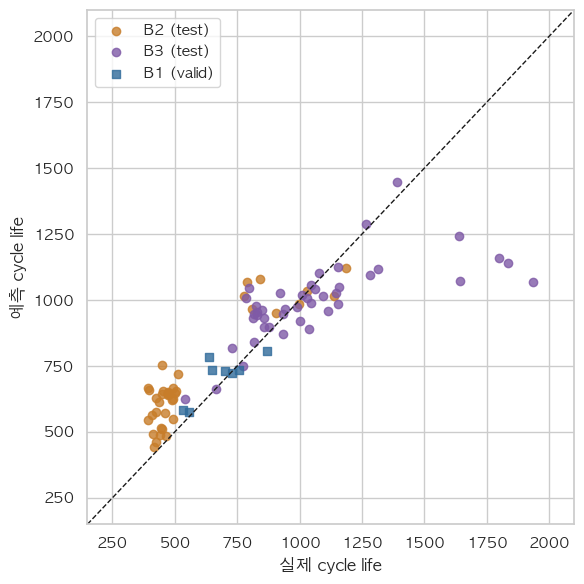

In [6]:
pred = out["pred"]

fig, ax = plt.subplots(figsize=(6, 6))
# 홀드아웃(valid)은 네모, 테스트(B2·B3)는 동그라미
for (split, b), g in pred.groupby(["split", "batch"]):
    ax.scatter(g.cycle_life, g.pred, label=f"{b} ({split})", color=BATCH_COLOR[b], alpha=0.8,
               marker="o" if split == "test" else "s")
lim = [150, 2100]; ax.plot(lim, lim, "k--", lw=1)   # y = x (완벽한 예측)
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_xlabel("실제 cycle life"); ax.set_ylabel("예측 cycle life"); ax.legend()
plt.tight_layout(); plt.savefig(ROOT / "results" / "pred_vs_actual.png", dpi=150); plt.show()

## 5. 오류 분석
- 가장 크게 틀린 셀의 공통점, 원인 가설, 개선 방향

In [7]:
# 절대 백분율 오차(ape_%) 상위 10셀 → 10개 중 9개가 B2 standard
pred.sort_values("ape_%", ascending=False)[
    ["cell_id", "batch", "group", "policy", "cycle_life", "pred", "ape_%", "log_var_dQ"]].head(10).round(1)

,cell_id,batch,group,policy,cycle_life,pred,ape_%,log_var_dQ
14,B2_c06,B2,standard,3.6C(9%)-5C,393.0,665.0,69.2,-3.5
26,B2_c18,B2,standard,5.2C(50%)-4.25C,449.0,753.2,67.8,-3.7
23,B2_c15,B2,standard,3.6C(9%)-5C,396.0,658.1,66.2,-3.5
10,B2_c02,B2,standard,5.2C(50%)-4.25C,424.0,630.2,48.6,-3.5
83,B3_c38,B3,newstructure,5C(67%)-4C-newstructure,1935.0,1069.3,44.7,-4.3
35,B2_c29,B2,standard,5.2C(58%)-4C,452.0,654.1,44.7,-3.5
19,B2_c11,B2,standard,5.2C(50%)-4.25C,449.0,642.7,43.1,-3.5
30,B2_c24,B2,standard,4.8C(80%)-4.8C,514.0,720.1,40.1,-3.6
34,B2_c28,B2,standard,4.8C(80%)-4.8C,437.0,611.9,40.0,-3.4
27,B2_c19,B2,standard,6C(60%)-3C,392.0,546.4,39.4,-3.3


### 5-1. 오차 방향 — 배치·실험집단별 평균 부호 오차
(+) = 수명을 길게 예측

In [8]:
test = pred[pred["split"] == "test"].assign(signed_err=lambda d: (d.pred - d.cycle_life) / d.cycle_life * 100)
test.groupby(["batch", "group"]).agg(n=("cell_id", "size"), signed_err_mean=("signed_err", "mean"),
                                     over_rate=("signed_err", lambda s: (s > 0).mean() * 100)).round(1)

n  signed_err_mean  over_rate
batch group                                       
B2    newstructure   9             11.3       66.7
      standard      30             32.6      100.0
B3    newstructure  44             -1.9       50.0

### 5-2. 같은 ΔQ, 다른 수명 — ΔQ ↔ 수명 관계의 배치 이동
B2 standard 셀은 ΔQ 값이 B1 학습 범위 안에 있어도 수명이 훨씬 짧다 → 모델이 B1의 관계를 그대로 적용해 과대 예측

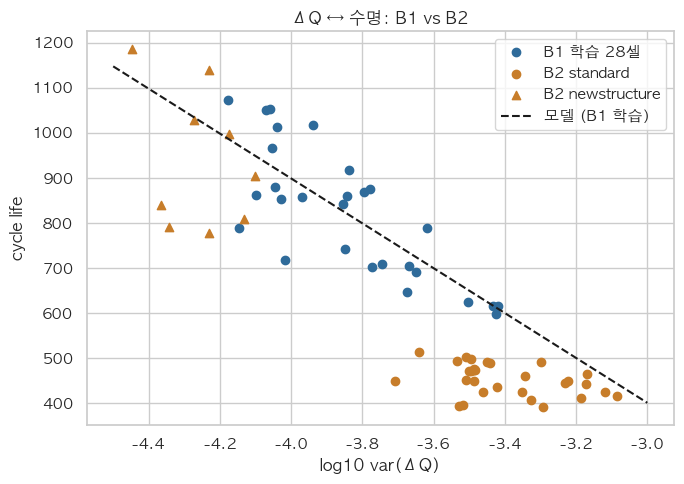

In [9]:
train = out["train"]
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(train.log_var_dQ, train.cycle_life, color=BATCH_COLOR["B1"], label="B1 학습 28셀")
for grp, marker in [("standard", "o"), ("newstructure", "^")]:
    d = test[(test.batch == "B2") & (test.group == grp)]
    ax.scatter(d.log_var_dQ, d.cycle_life, color=BATCH_COLOR["B2"], marker=marker, label=f"B2 {grp}")
# 최종 모델의 예측선 (B1 관계)
x = np.linspace(-4.5, -3.0, 100)
ax.plot(x, out["model"].predict(pd.DataFrame({"log_var_dQ": x})), "k--", label="모델 (B1 학습)")
ax.set_xlabel("log10 var(ΔQ)"); ax.set_ylabel("cycle life"); ax.legend(); ax.set_title("ΔQ ↔ 수명: B1 vs B2")
plt.tight_layout(); plt.savefig(ROOT / "results" / "dq_shift_b1_b2.png", dpi=150); plt.show()

### 5-3. 같은 충전 정책의 배치 비교
정책을 고정해도 B2 셀의 수명이 짧다 → 정책·ΔQ 밖의 배치 요인

In [10]:
feat_all = pd.concat([out["train"], out["holdout"], test], ignore_index=True)
same = feat_all[feat_all.policy.isin(["6C(60%)-3C", "4.8C(80%)-4.8C"])]
same.groupby(["policy", "batch", "group"]).agg(
    n=("cell_id", "size"), life_mean=("cycle_life", "mean"), log_var_dQ=("log_var_dQ", "mean")).round(2)

n  life_mean  log_var_dQ
policy         batch group                             
4.8C(80%)-4.8C B1    standard  2      753.0       -3.79
               B2    standard  5      483.6       -3.50
6C(60%)-3C     B1    standard  2      744.0       -3.66
               B2    standard  2      400.0       -3.31